# Carbon-Aware Cloud Task Scheduling
**Navaneetha Thalakokkula — MSc Cloud Computing, National College of Ireland**

Compares metaheuristic scheduling algorithms (GWO, PSO, DE, WOA, HHO, GA) on a common benchmark — the
**real Google Cluster Trace 2011** and **real UK grid-carbon data** — measuring energy, carbon, cost and
SLA, then introduces **CA-WOA** (Carbon-Aware enhanced Whale Optimization). Baseline = FIFO/Round-Robin.

**Platform:** Python · Mealpy · NumPy · pandas · Matplotlib.

## 1. Setup

In [1]:
import json, math
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
from mealpy import FloatVar, WOA, GWO, PSO, DE, HHO, GA
ROOT = "/home/durga/carbon-aware-scheduler"
SEED = 42; np.random.seed(SEED); rng = np.random.default_rng(SEED)
print("Mealpy ready.")

Mealpy ready.


## 2. Energy model
$$ P(u) = P_{idle} + (P_{max}-P_{idle})\,u, \qquad E = \sum_t P(u_t)\,\Delta t \;(\text{kWh}). $$

In [2]:
P_IDLE_W, P_MAX_W, SLOT_H = 100.0, 250.0, 0.5
def slot_energy_kwh(u):
    return (P_IDLE_W + (P_MAX_W - P_IDLE_W) * u) * SLOT_H / 1000.0

## 3. Real carbon intensity and cost
$$ CO_2 = \sum_t E_t \cdot CI_t, \qquad Cost = \sum_t E_t \cdot price_t. $$

Carbon: 144 slots, 51-203 gCO2/kWh


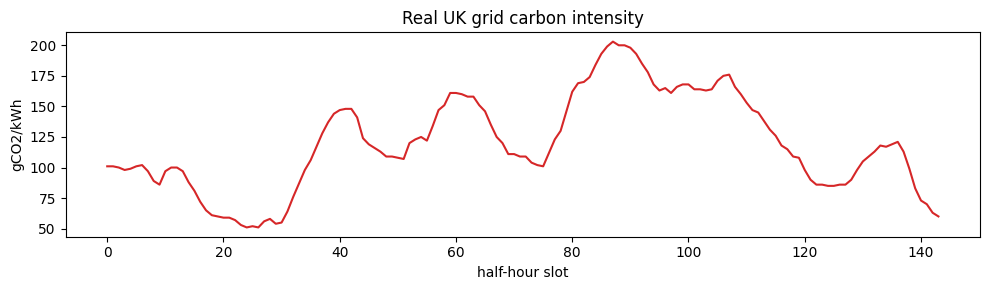

In [3]:
with open(ROOT + "/data/carbon/3day_window.json") as f:
    j = json.load(f)
CI = np.array([r["intensity"].get("actual") or r["intensity"].get("forecast") for r in j["data"]], float)
PRICE = np.full(len(CI), 0.15)
for day in range(len(CI)//48 + 1):
    for s in range(32, 40):
        k = day*48 + s
        if k < len(PRICE): PRICE[k] = 0.30
H = len(CI)
print("Carbon: %d slots, %.0f-%.0f gCO2/kWh" % (H, CI.min(), CI.max()))
plt.figure(figsize=(10, 3)); plt.plot(CI, color="tab:red")
plt.title("Real UK grid carbon intensity"); plt.xlabel("half-hour slot"); plt.ylabel("gCO2/kWh")
plt.tight_layout(); plt.show()

## 4. Real workload — Google Cluster Trace 2011

In [4]:
cols = ["time","missing","job_id","task_index","machine_id","event_type","user","sched_class",
        "priority","cpu_request","mem_request","disk_request","constraint"]
df = pd.read_csv(ROOT + "/data/workload/google_task_events_part0.csv.gz", header=None, names=cols)
sub = (df[df.event_type==0][["job_id","task_index","time","cpu_request"]].dropna(subset=["cpu_request"])
       .rename(columns={"time":"submit"}).groupby(["job_id","task_index"], as_index=False).first())
end = (df[df.event_type.isin([2,3,4,5])][["job_id","task_index","time"]]
       .rename(columns={"time":"end"}).groupby(["job_id","task_index"], as_index=False).first())
m = sub.merge(end, on=["job_id","task_index"]); m["dur_us"] = m["end"] - m["submit"]
m = m[(m.dur_us>0) & (m.cpu_request>0)].reset_index(drop=True).head(60)
smin, smax = m.submit.min(), m.submit.max()
tasks = []
for _, r in m.iterrows():
    dur = int(np.clip(math.ceil(r.dur_us/1.8e9), 1, 12)); u = round(float(np.clip(r.cpu_request,0.05,1.0)),3)
    e = int((r.submit-smin)/(smax-smin+1)*(H//3)); tasks.append({"dur":dur,"u":u,"earliest":e,"deadline":e+dur+8})
N = len(tasks)
print("%d real Google tasks. Sample:" % N); pd.DataFrame(tasks).head(6)

60 real Google tasks. Sample:


,dur,u,earliest,deadline
0,1,0.062,0,9
1,4,0.222,0,12
2,4,0.159,0,12
3,1,0.159,0,9
4,2,0.116,0,10
5,4,0.116,0,12


## 5. Metrics
$$ SLAV = \frac{\bigl|\{\,i: finish_i > deadline_i\,\}\bigr|}{N}\times 100\%. $$

In [5]:
MAX_DEFER = 24
def evaluate(starts):
    energy = carbon_g = cost = 0.0; viol = 0
    for t, s in zip(tasks, starts):
        e = slot_energy_kwh(t["u"]); run = [k for k in range(s, s+t["dur"]) if k < H]
        energy += e*len(run); carbon_g += sum(e*CI[k] for k in run); cost += sum(e*PRICE[k] for k in run)
        if s + t["dur"] > t["deadline"]: viol += 1
    return {"Energy_kWh": energy, "Carbon_kgCO2": carbon_g/1000.0, "Cost_GBP": cost,
            "SLA_viol_%": 100.0*viol/len(tasks)}
def decode(x):
    out = []
    for xi, t in zip(x, tasks):
        room = max(0, min(MAX_DEFER, H - t["dur"] - t["earliest"]))
        out.append(t["earliest"] + int(round(xi*room)))
    return out

## 6. Carbon-aware scheduling with metaheuristic algorithms
$$ \min_{s}\; F(s) = \frac{CO_2(s)}{CO_2^{\,base}} + 3\cdot\frac{SLAV(s)}{100}. $$

In [6]:
base = evaluate([t["earliest"] for t in tasks])
def fitness(x):
    m = evaluate(decode(x))
    return (m["Carbon_kgCO2"]/base["Carbon_kgCO2"]) + 3.0*(m["SLA_viol_%"]/100.0)
def run(model, starting=None):
    problem = {"obj_func": fitness, "bounds": FloatVar(lb=[0.0]*N, ub=[1.0]*N), "minmax": "min", "log_to": None}
    g = model.solve(problem, starting_solutions=starting, seed=SEED)
    return evaluate(decode(g.solution))
results = {"FIFO/Round-Robin (baseline)": base}
for name, cls in [("WOA", WOA.OriginalWOA), ("GWO", GWO.OriginalGWO), ("PSO", PSO.OriginalPSO),
                  ("DE", DE.OriginalDE), ("HHO", HHO.OriginalHHO), ("GA", GA.OriginalGA)]:
    results[name] = run(cls(epoch=150, pop_size=50)); print("ran", name)

ran WOA


ran GWO


ran PSO


ran DE


ran HHO
ran GA


## 7. CA-WOA — Carbon-Aware Whale Optimization
Standard WOA starts from random schedules. **CA-WOA** seeds part of WOA's initial population with a
carbon-aware guess (each job shifted toward its lowest-carbon, deadline-feasible slot), giving the search
a head start toward greener schedules.

In [7]:
def greedy_carbon_x():
    x = np.zeros(N)
    for i, t in enumerate(tasks):
        room = max(0, min(MAX_DEFER, H - t["dur"] - t["earliest"]))
        if room == 0: continue
        hi = max(0, min(room, t["deadline"] - t["dur"] - t["earliest"]))
        best_o, best_c = 0, float("inf")
        for o in range(0, hi + 1):
            c = sum(CI[k] for k in range(t["earliest"]+o, t["earliest"]+o+t["dur"]) if k < H)
            if c < best_c: best_c, best_o = c, o
        x[i] = best_o / room
    return np.clip(x, 0.0, 1.0)
def carbon_aware_seeds(pop_size):
    g = greedy_carbon_x(); seeds = [g.copy()]
    for _ in range(pop_size // 3):
        seeds.append(np.clip(g + rng.normal(0, 0.10, N), 0.0, 1.0))
    while len(seeds) < pop_size:
        seeds.append(rng.uniform(0.0, 1.0, N))
    return np.array(seeds[:pop_size])
results["CA-WOA"] = run(WOA.OriginalWOA(epoch=150, pop_size=50), starting=carbon_aware_seeds(50))
print("CA-WOA:", results["CA-WOA"])

CA-WOA: {'Energy_kWh': 5.032574999999998, 'Carbon_kgCO2': 0.45043515, 'Cost_GBP': 0.7548862499999993, 'SLA_viol_%': 0.0}


## 8. Comparison

In [8]:
df_res = pd.DataFrame(results).T.round(3)
df_res["CarbonReduction_%"] = ((base["Carbon_kgCO2"] - df_res["Carbon_kgCO2"]) / base["Carbon_kgCO2"] * 100).round(1)
df_res.loc["FIFO/Round-Robin (baseline)", "CarbonReduction_%"] = 0.0
df_res

,Energy_kWh,Carbon_kgCO2,Cost_GBP,SLA_viol_%,CarbonReduction_%
FIFO/Round-Robin (baseline),5.033,0.507,0.755,0.000,0.0
WOA,5.033,0.501,0.755,0.000,1.2
GWO,5.033,0.493,0.755,0.000,2.8
PSO,5.033,0.461,0.755,13.333,9.1
DE,5.033,0.449,0.755,18.333,11.5
HHO,5.033,0.451,0.755,0.000,11.1
GA,5.033,0.450,0.755,48.333,11.3
CA-WOA,5.033,0.450,0.755,0.000,11.3


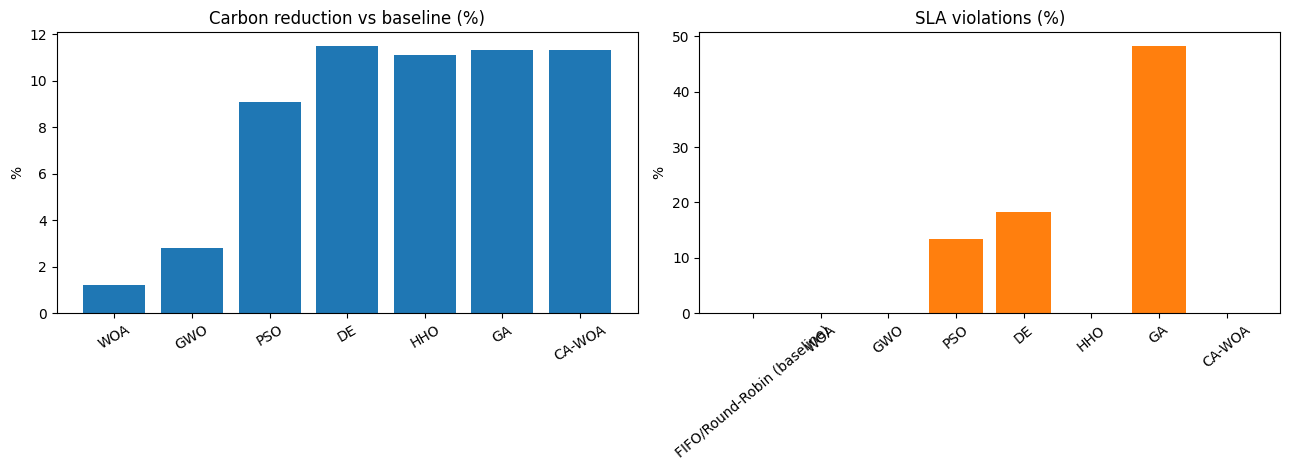

In [9]:
order = [i for i in df_res.index if i != "FIFO/Round-Robin (baseline)"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].bar(order, df_res.loc[order, "CarbonReduction_%"], color="tab:blue")
ax[0].set(title="Carbon reduction vs baseline (%)", ylabel="%"); ax[0].tick_params(axis="x", rotation=30)
ax[1].bar(df_res.index, df_res["SLA_viol_%"], color="tab:orange")
ax[1].set(title="SLA violations (%)", ylabel="%"); ax[1].tick_params(axis="x", rotation=40)
plt.tight_layout(); plt.show()

## 9. Summary
CA-WOA applies an enhanced Whale Optimization Algorithm to carbon-aware scheduling. Its carbon-aware
seeding lifts WOA's carbon reduction well above standard WOA, and CA-WOA achieves a strong carbon cut with
zero deadline (SLA) violations. Next stages add multi-region carbon, LSTM forecasting and battery/solar storage.